# Network Traffic Anomaly Detection — End-to-End EDA and Model Training

## Required Models
This notebook trains and evaluates **two supervised machine learning models**:

1. Logistic Regression
2. Random Forest Classifier

## Dataset
CIC-IDS 2017 files used:
- `Monday-WorkingHours.pcap_ISCX.csv` — normal/benign traffic
- `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` — DDoS traffic

## Objective
Build a binary classifier that detects whether network traffic is:

- `BENIGN`
- `DDoS`

## 1. Mount Google Drive

Run this cell only if you are using Google Colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Import Libraries

In [2]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 3. Set Dataset Paths

Update `DATA_DIR` if your files are stored in a different Google Drive folder.

In [3]:
DATA_DIR = "/content/drive/MyDrive/dataset"

monday_file = os.path.join(DATA_DIR, "Monday-WorkingHours.pcap_ISCX.csv")
friday_ddos_file = os.path.join(DATA_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Monday file exists:", os.path.exists(monday_file))
print("Friday DDoS file exists:", os.path.exists(friday_ddos_file))

Monday file exists: True
Friday DDoS file exists: True


## 4. Load the Dataset

In [4]:
df_monday = pd.read_csv(monday_file)
df_friday = pd.read_csv(friday_ddos_file)

print("Monday dataset shape:", df_monday.shape)
print("Friday DDoS dataset shape:", df_friday.shape)

Monday dataset shape: (529918, 79)
Friday DDoS dataset shape: (225745, 79)


## 5. Standardize Column Names

The CIC-IDS 2017 CSV files often contain leading or trailing spaces in column names.

In [5]:
df_monday.columns = df_monday.columns.str.strip()
df_friday.columns = df_friday.columns.str.strip()

print("Monday columns:")
print(df_monday.columns.tolist())

print("\nFriday columns:")
print(df_friday.columns.tolist())

Monday columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count',

## 6. Initial Data Preview

In [6]:
print("Monday dataset preview:")
display(df_monday.head())

print("\nFriday DDoS dataset preview:")
display(df_friday.head())

Monday dataset preview:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Friday DDoS dataset preview:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 7. Check Label Distribution Before Merging

In [7]:
print("Monday label distribution:")
print(df_monday["Label"].value_counts())

print("\nFriday DDoS label distribution:")
print(df_friday["Label"].value_counts())

Monday label distribution:
Label
BENIGN    529918
Name: count, dtype: int64

Friday DDoS label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


## 8. Merge the Datasets

In [8]:
df = pd.concat([df_monday, df_friday], axis=0, ignore_index=True)

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (755663, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# 9. Exploratory Data Analysis

This section examines the dataset before model training.

## 9.1 Dataset Shape, Columns, and Data Types

In [9]:
print("Dataset shape:", df.shape)

summary_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum().values,
    "Unique Values": df.nunique().values
})

display(summary_df)

Dataset shape: (755663, 79)


,Column,Data Type,Missing Values,Unique Values
Destination Port,Destination Port,int64,0,38349
Flow Duration,Flow Duration,int64,0,392196
Total Fwd Packets,Total Fwd Packets,int64,0,697
Total Backward Packets,Total Backward Packets,int64,0,898
Total Length of Fwd Packets,Total Length of Fwd Packets,int64,0,10138
...,...,...,...,...
Idle Mean,Idle Mean,float64,0,109795
Idle Std,Idle Std,float64,0,49694
Idle Max,Idle Max,int64,0,97150
Idle Min,Idle Min,int64,0,113353


## 9.2 Class Distribution

Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


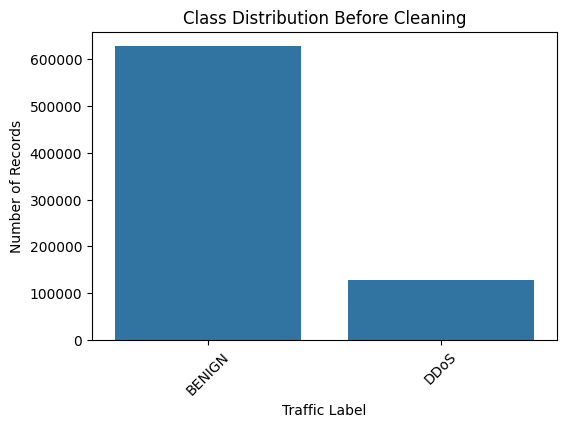

In [10]:
label_counts = df["Label"].value_counts()

print(label_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Label", order=label_counts.index)
plt.title("Class Distribution Before Cleaning")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

## 9.3 Duplicate Rows

In [11]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round((duplicate_count / len(df)) * 100, 2), "%")

Duplicate rows: 29629
Duplicate percentage: 3.92 %


## 9.4 Missing Values

,Missing Values
Flow Bytes/s,68


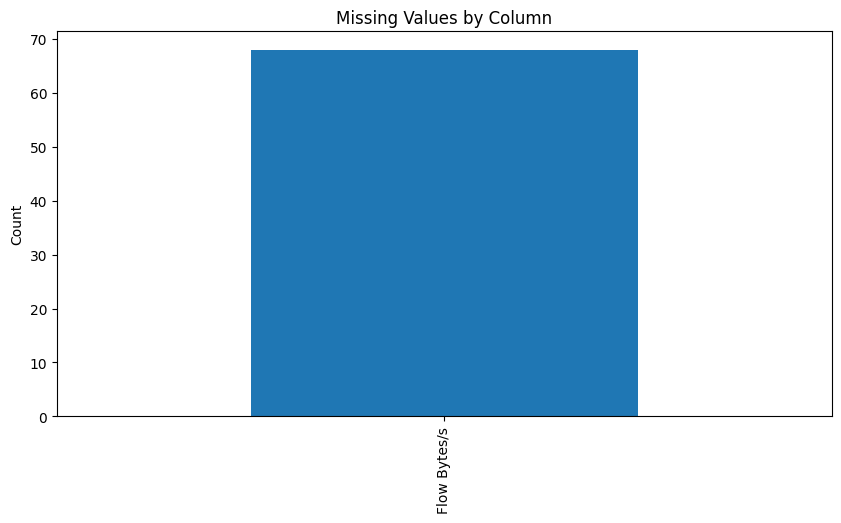

In [12]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values.to_frame("Missing Values"))

    plt.figure(figsize=(10, 5))
    missing_values.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.ylabel("Count")
    plt.show()

## 9.5 Descriptive Statistics for Numeric Features

In [13]:
numeric_df = df.select_dtypes(include=[np.number])

print("Number of numeric columns:", numeric_df.shape[1])
display(numeric_df.describe().T)

Number of numeric columns: 78


,count,mean,std,min,25%,50%,75%,max
Destination Port,755663.0,1.011717e+04,2.093059e+04,0.0,53.0,80.0,443.0,6.553500e+04
Flow Duration,755663.0,1.213760e+07,2.972829e+07,-1.0,225.0,63039.0,4256727.5,1.200000e+08
Total Fwd Packets,755663.0,8.742658e+00,7.473706e+02,1.0,2.0,2.0,5.0,2.197590e+05
Total Backward Packets,755663.0,9.442572e+00,9.826305e+02,0.0,1.0,2.0,5.0,2.919220e+05
Total Length of Fwd Packets,755663.0,6.540189e+02,5.513176e+03,0.0,24.0,56.0,128.0,1.323378e+06
...,...,...,...,...,...,...,...,...
Active Min,755663.0,8.377969e+04,6.019684e+05,0.0,0.0,0.0,0.0,1.016597e+08
Idle Mean,755663.0,5.512728e+06,1.644670e+07,0.0,0.0,0.0,0.0,1.200000e+08
Idle Std,755663.0,1.220987e+06,7.372506e+06,0.0,0.0,0.0,0.0,7.514502e+07
Idle Max,755663.0,6.386213e+06,1.898697e+07,0.0,0.0,0.0,0.0,1.200000e+08


## 9.6 Check Infinite Values

Some CIC-IDS 2017 features, especially flow-rate features, can contain infinite values.

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
inf_counts = inf_counts[inf_counts > 0].sort_values(ascending=False)

if len(inf_counts) == 0:
    print("No infinite values found.")
else:
    print("Columns with infinite values:")
    display(inf_counts.to_frame("Infinite Values"))

Columns with infinite values:


,Infinite Values
Flow Packets/s,471
Flow Bytes/s,403


# 10. Data Cleaning

## 10.1 Keep Only BENIGN and DDoS Labels

In [15]:
df_clean = df[df["Label"].isin(["BENIGN", "DDoS"])].copy()

print("Shape after keeping BENIGN and DDoS:", df_clean.shape)
print(df_clean["Label"].value_counts())

Shape after keeping BENIGN and DDoS: (755663, 79)
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


## 10.2 Remove Duplicate Rows

In [16]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().copy()
after = df_clean.shape[0]

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Rows removed:", before - after)

Rows before duplicate removal: 755663
Rows after duplicate removal: 726034
Rows removed: 29629


## 10.3 Replace Infinite Values with Missing Values

In [17]:
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Total missing values after replacing infinity:", df_clean.isna().sum().sum())

Total missing values after replacing infinity: 720


## 10.4 Drop Rows with Missing Values

In [18]:
before = df_clean.shape[0]
df_clean = df_clean.dropna().copy()
after = df_clean.shape[0]

print("Rows before dropping missing values:", before)
print("Rows after dropping missing values:", after)
print("Rows removed:", before - after)

Rows before dropping missing values: 726034
Rows after dropping missing values: 725674
Rows removed: 360


## 10.5 Remove Potential Leakage Columns

These fields can make the model memorize traffic identity instead of learning traffic behavior.

In [19]:
leakage_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
existing_leakage_cols = [col for col in leakage_cols if col in df_clean.columns]

df_clean = df_clean.drop(columns=existing_leakage_cols)

print("Dropped leakage columns:", existing_leakage_cols)
print("Cleaned dataset shape:", df_clean.shape)

Dropped leakage columns: []
Cleaned dataset shape: (725674, 79)


## 10.6 Final Cleaned Dataset Check

In [20]:
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Remaining duplicate rows:", df_clean.duplicated().sum())
print("\nFinal label distribution:")
print(df_clean["Label"].value_counts())

Remaining missing values: 0
Remaining duplicate rows: 0

Final label distribution:
Label
BENIGN    597660
DDoS      128014
Name: count, dtype: int64


# 11. EDA After Cleaning

## 11.1 Cleaned Class Distribution

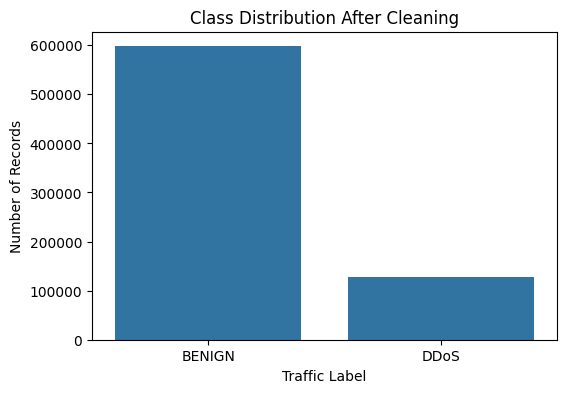

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Label", order=df_clean["Label"].value_counts().index)
plt.title("Class Distribution After Cleaning")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Records")
plt.show()

## 11.2 Selected Features for Modeling

These features describe traffic volume, packet behavior, and TCP flag behavior.

In [22]:
selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "SYN Flag Count",
    "ACK Flag Count",
    "PSH Flag Count",
    "Average Packet Size"
]

missing_features = [feature for feature in selected_features if feature not in df_clean.columns]

if missing_features:
    raise ValueError(f"Missing selected features: {missing_features}")
else:
    print("All selected features are available.")

All selected features are available.


## 11.3 Feature Summary by Class

In [23]:
feature_summary = df_clean.groupby("Label")[selected_features].mean().T
display(feature_summary)

Label,BENIGN,DDoS
Flow Duration,1.169214e+07,1.695716e+07
Total Fwd Packets,9.985616e+00,4.472683e+00
Total Backward Packets,1.119034e+01,3.256081e+00
Total Length of Fwd Packets,8.165636e+02,3.191057e+01
Total Length of Bwd Packets,1.653696e+04,7.374351e+03
Flow Bytes/s,1.452709e+06,6.050989e+04
Flow Packets/s,5.253027e+04,1.553888e+02
Packet Length Mean,1.258554e+02,7.369488e+02
SYN Flag Count,6.728240e-02,0.000000e+00
ACK Flag Count,3.315263e-01,5.467761e-01


## 11.4 Feature Distributions

A sample is used for plotting to avoid slow rendering on very large datasets.

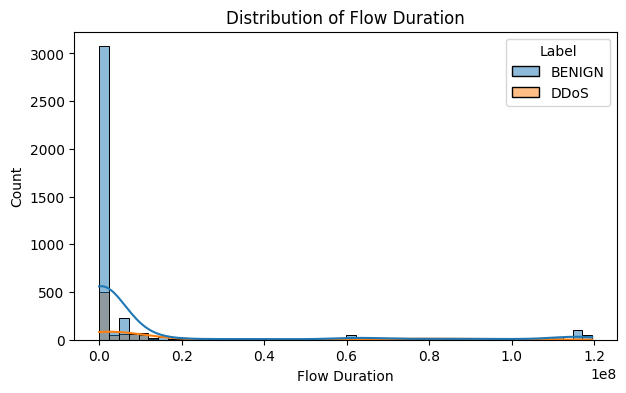

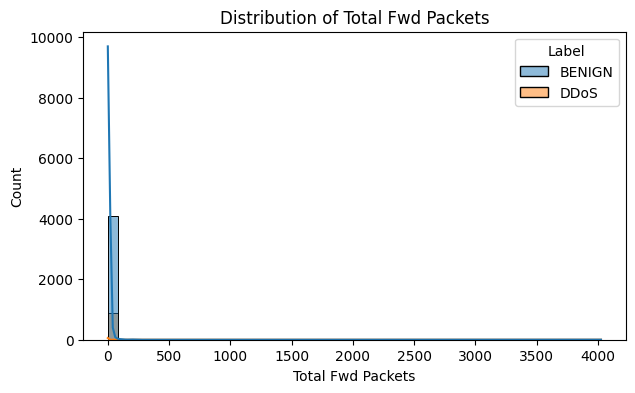

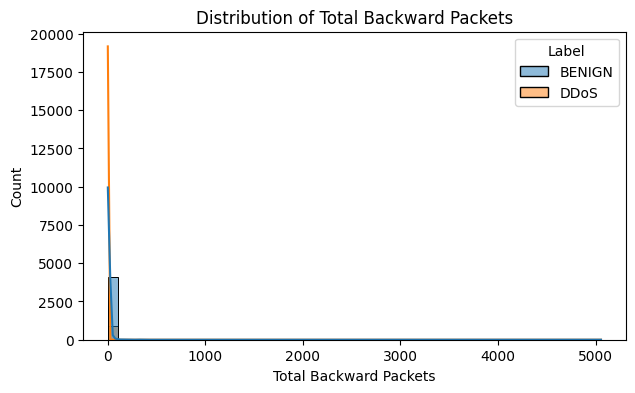

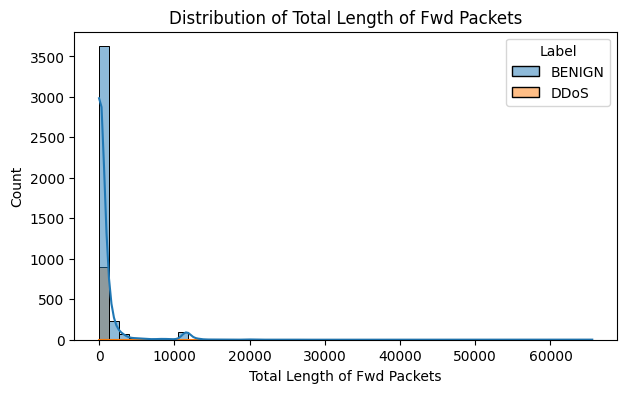

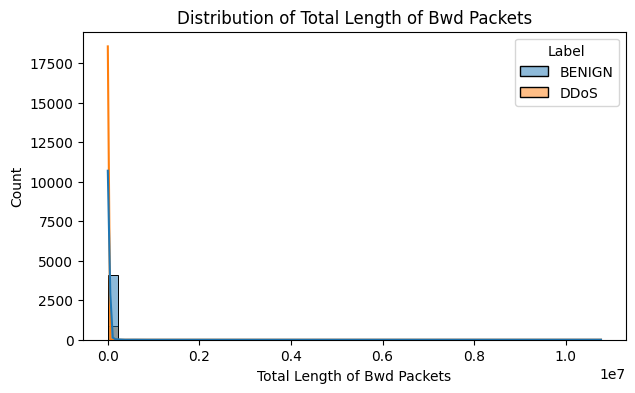

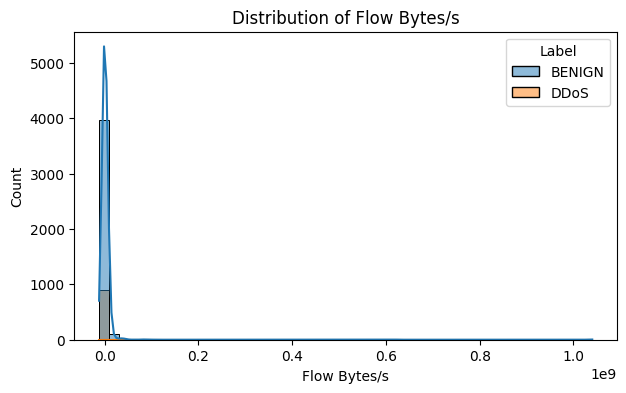

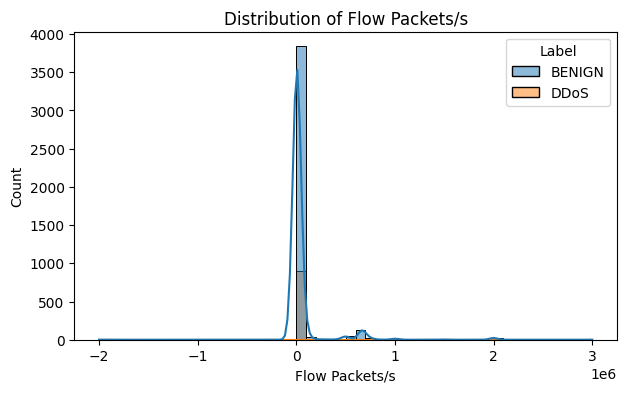

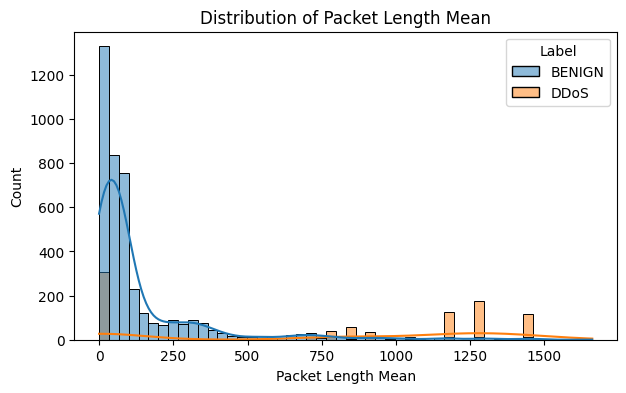

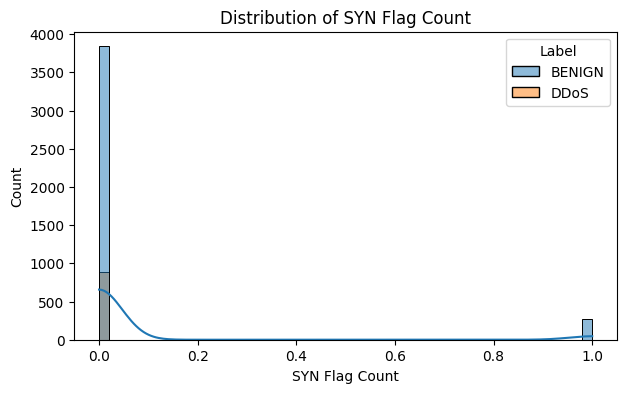

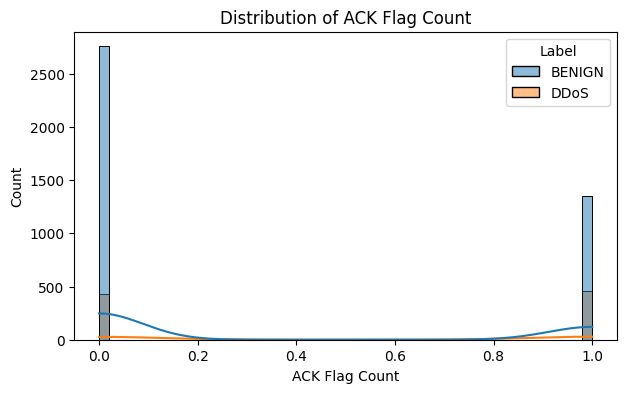

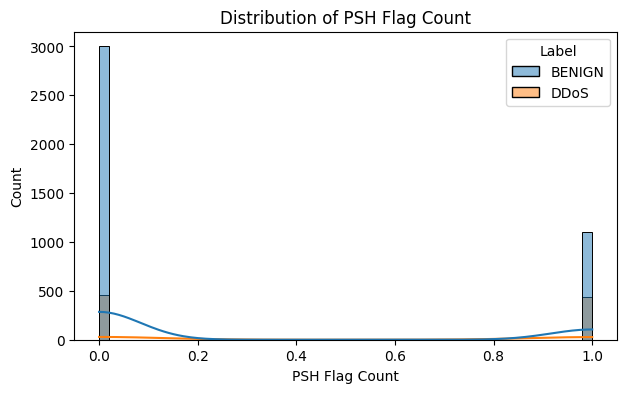

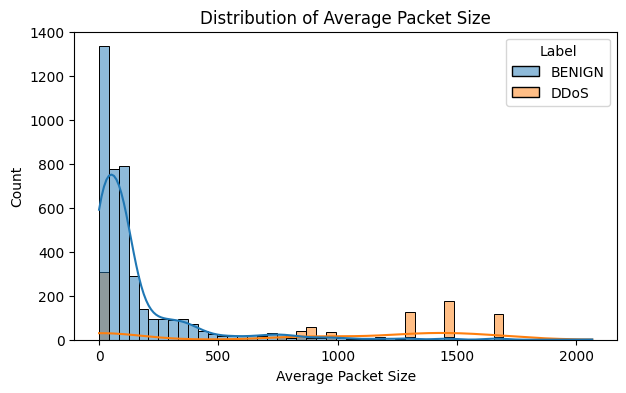

In [24]:
plot_sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=RANDOM_STATE)

for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=plot_sample, x=feature, hue="Label", kde=True, bins=50)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

## 11.5 Boxplots by Class

These plots help identify differences between BENIGN and DDoS traffic patterns.

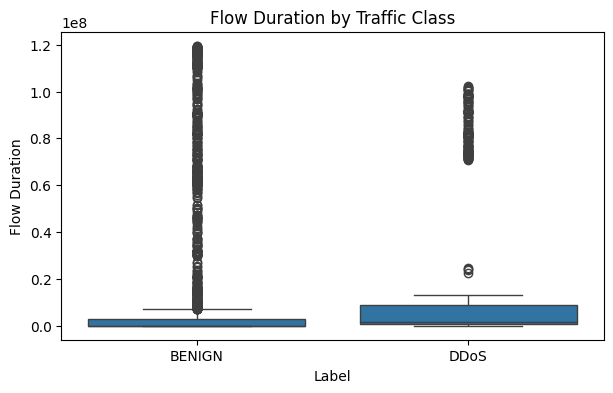

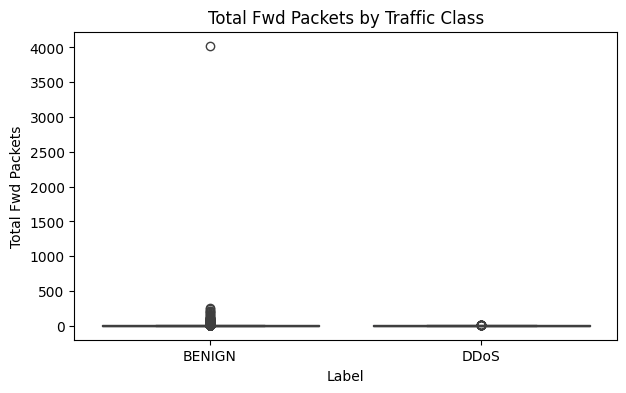

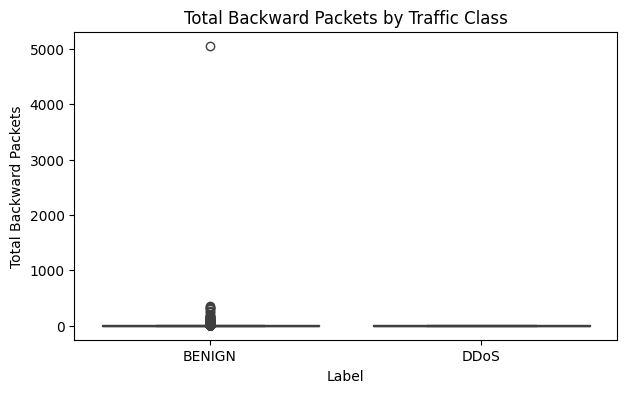

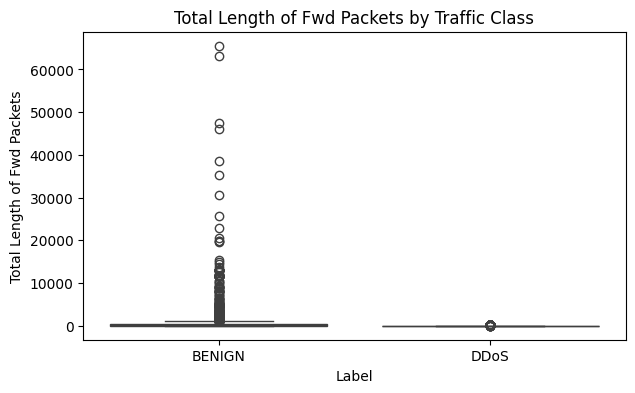

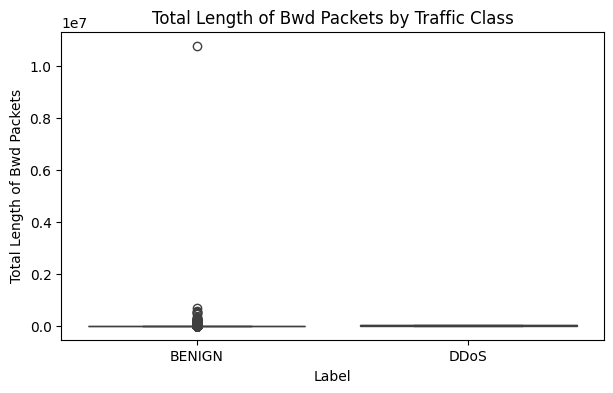

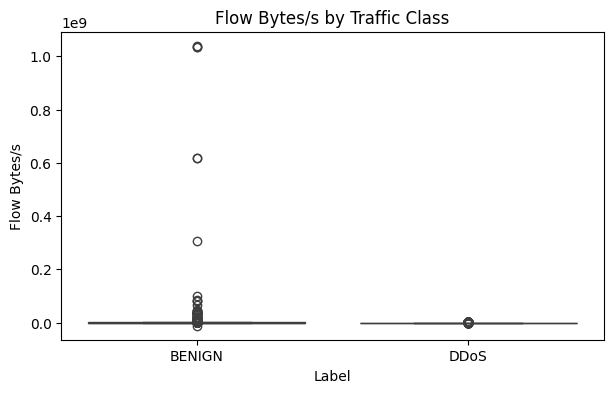

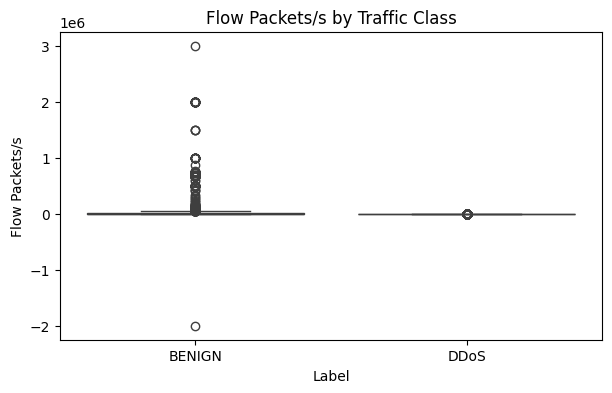

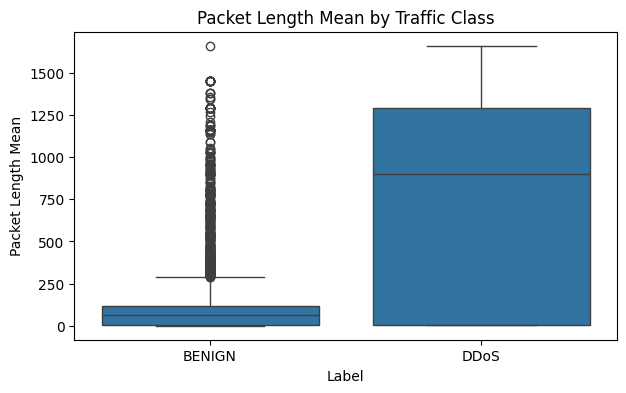

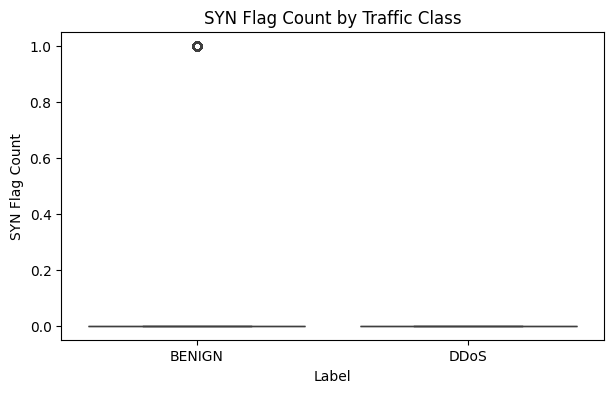

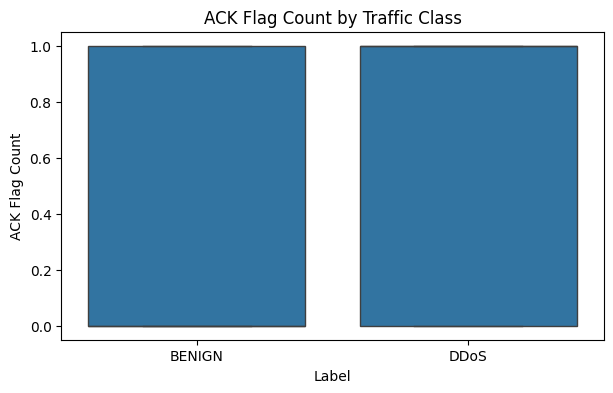

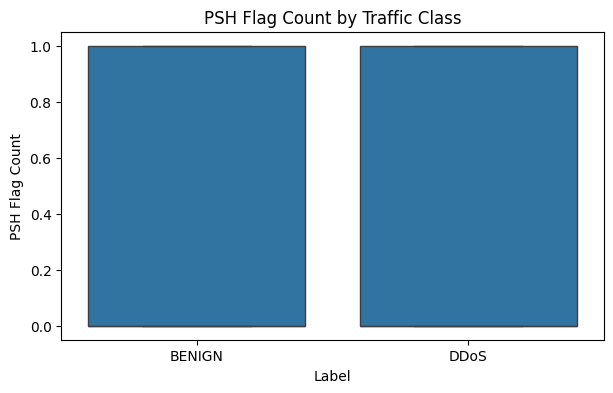

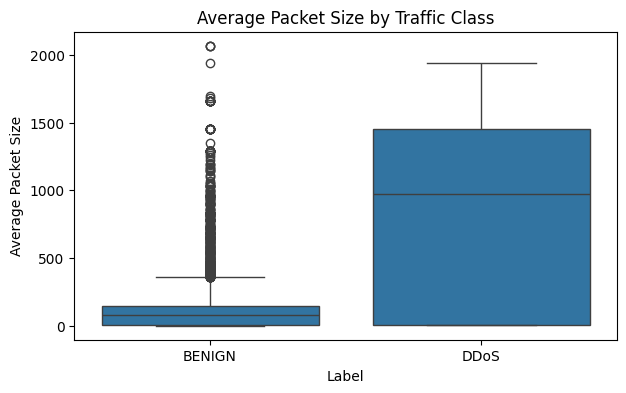

In [25]:
for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=plot_sample, x="Label", y=feature)
    plt.title(f"{feature} by Traffic Class")
    plt.xlabel("Label")
    plt.ylabel(feature)
    plt.show()

## 11.6 Correlation Heatmap

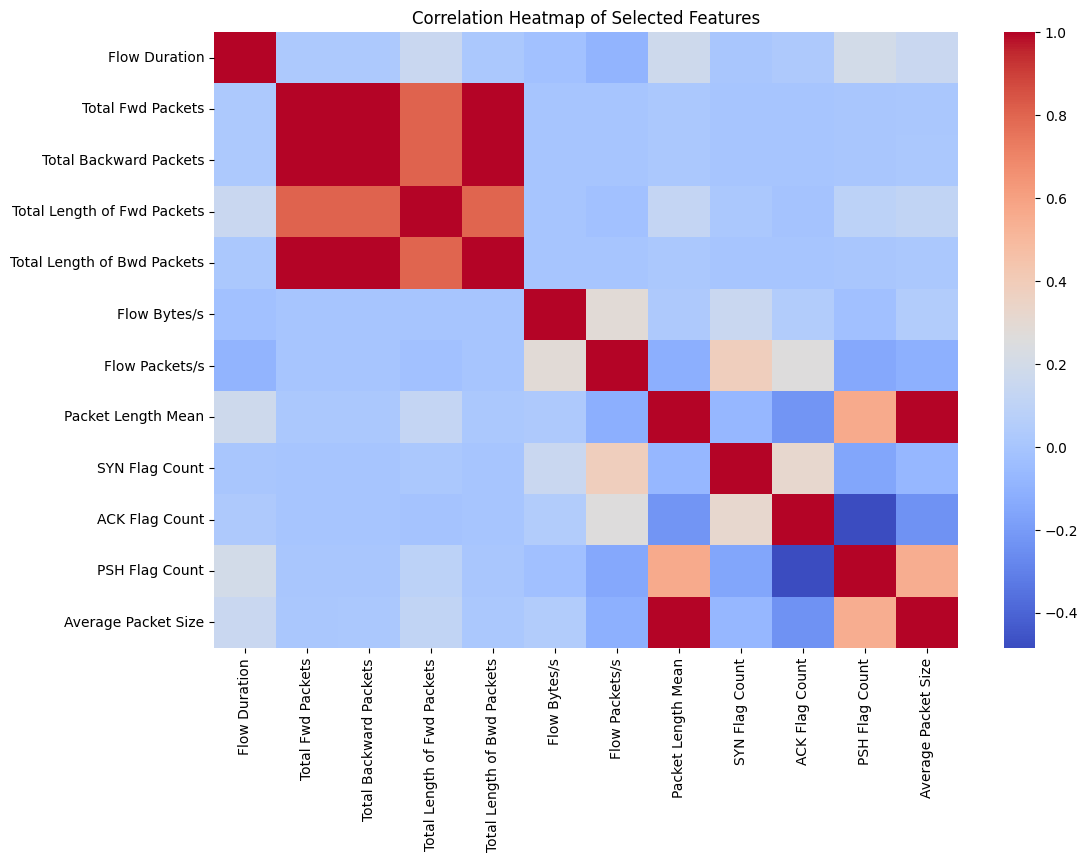

In [26]:
corr = df_clean[selected_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

# 12. Prepare Data for Modeling

## 12.1 Create Model Dataset

In [27]:
model_df = df_clean[selected_features + ["Label"]].copy()

model_df["Label"] = model_df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Model dataset shape:", model_df.shape)
print(model_df["Label"].value_counts())
display(model_df.head())

Model dataset shape: (725674, 13)
Label
0    597660
1    128014
Name: count, dtype: int64


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size,Label
0,4,2,0,12,0,3.000000e+06,5.000000e+05,6.000000,0,1,0,9.000000,0
1,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,0
4,3,2,0,12,0,4.000000e+06,6.666667e+05,6.000000,0,1,0,9.000000,0
5,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,0
8,609,7,4,484,414,1.474548e+06,1.806240e+04,74.833333,0,0,1,81.636364,0


## 12.2 Split Features and Target

In [28]:
X = model_df[selected_features]
y = model_df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (725674, 12)
y shape: (725674,)


## 12.3 Train/Test Split

Stratification keeps the class ratio similar in both training and testing datasets.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training set shape: (580539, 12)
Testing set shape: (145135, 12)

Training label distribution:
Label
0    478128
1    102411
Name: count, dtype: int64

Testing label distribution:
Label
0    119532
1     25603
Name: count, dtype: int64


## 12.4 Feature Scaling

Logistic Regression needs scaling. Random Forest does not strictly require scaling, but using the same scaled input keeps the pipeline consistent.

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=selected_features)

display(X_train_scaled_df.head())

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size
0,-0.417248,-0.009142,-0.008744,-0.113054,-0.006637,-0.053067,-0.225025,-0.589023,-0.242077,1.307592,-0.640938,-0.593887
1,0.159338,0.005603,0.000611,0.116645,-0.004991,-0.053088,-0.226054,-0.067904,-0.242077,-0.764764,1.560214,-0.107766
2,-0.415995,-0.009142,-0.008744,-0.115077,-0.006637,-0.053102,-0.225765,-0.600579,-0.242077,1.307592,-0.640938,-0.607794
3,3.410611,0.014203,0.007159,0.016878,-0.004160,-0.053100,-0.226060,-0.162083,-0.242077,-0.764764,1.560214,-0.201856
4,-0.416744,-0.007913,-0.008744,-0.106650,-0.006634,-0.053019,-0.225372,-0.568735,-0.242077,1.307592,-0.640938,-0.571866


# 13. Model Training and Evaluation

Only the two supervisor-requested models are trained:

1. Logistic Regression
2. Random Forest

## 13.1 Define Evaluation Function

In [31]:
def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_score)
    else:
        roc_auc = np.nan

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred),
        "Recall": recall_score(y_test_data, y_pred),
        "F1 Score": f1_score(y_test_data, y_pred),
        "ROC AUC": roc_auc
    }

    print(f"===== {model_name} =====")
    print(classification_report(y_test_data, y_pred, target_names=["BENIGN", "DDoS"]))

    cm = confusion_matrix(y_test_data, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "DDoS"])
    disp.plot()
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_test_data, y_test_data)
        plt.title(f"ROC Curve — {model_name}")
        plt.show()

    return metrics

## 13.2 Train Logistic Regression

===== Logistic Regression =====
              precision    recall  f1-score   support

      BENIGN       1.00      0.90      0.95    119532
        DDoS       0.68      1.00      0.81     25603

    accuracy                           0.92    145135
   macro avg       0.84      0.95      0.88    145135
weighted avg       0.94      0.92      0.92    145135



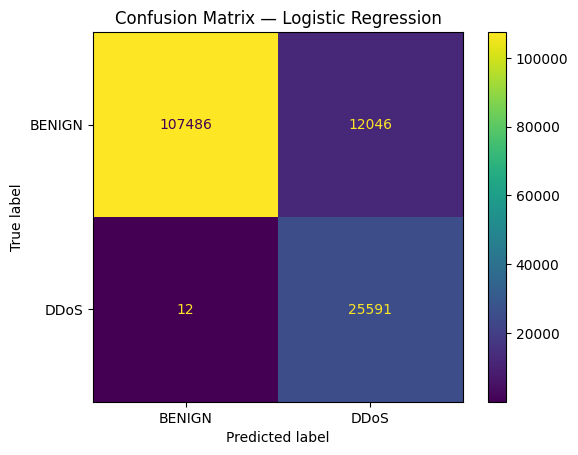

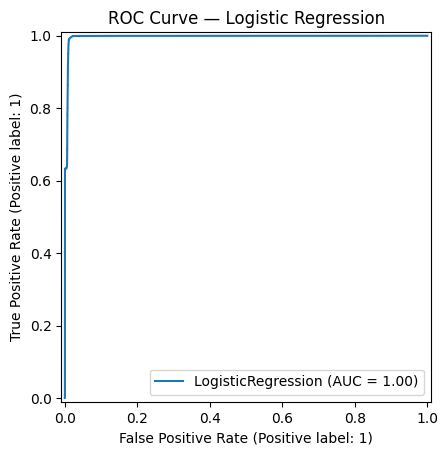

In [32]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logistic_model.fit(X_train_scaled_df, y_train)

logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test_scaled_df,
    y_test
)

## 13.3 Train Random Forest

===== Random Forest =====
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    119532
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00    145135
   macro avg       1.00      1.00      1.00    145135
weighted avg       1.00      1.00      1.00    145135



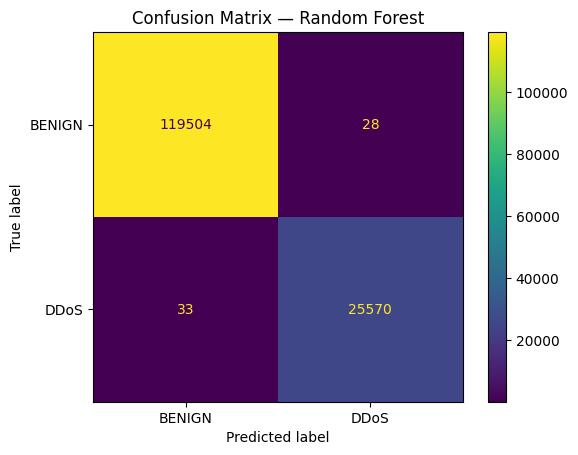

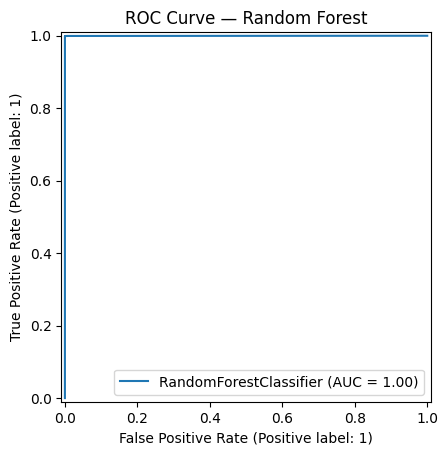

In [33]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(X_train_scaled_df, y_train)

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test_scaled_df,
    y_test
)

In [36]:
results_df = pd.DataFrame([logistic_results, random_forest_results])
results_df = results_df.sort_values(by="F1 Score", ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.999580,0.998906,0.998711,0.998809,0.999674
0,Logistic Regression,0.916919,0.679943,0.999531,0.809330,0.996930


## 13.4 Compare the Two Models

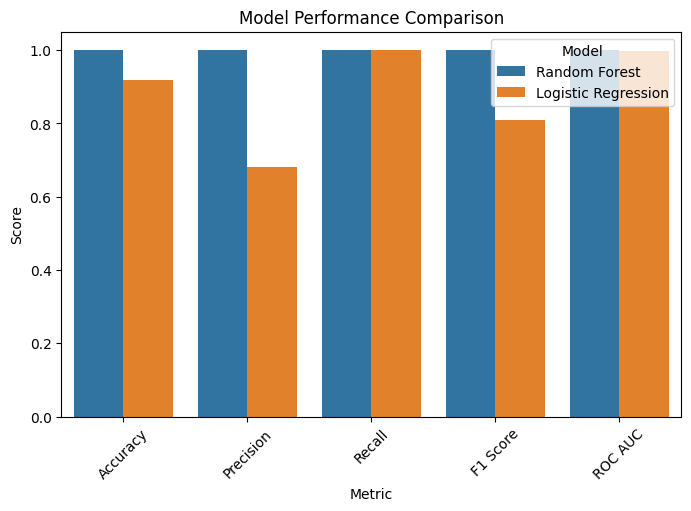

In [37]:
plt.figure(figsize=(8, 5))
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.show()

## 13.5 Cross-Validation

Cross-validation gives a more reliable estimate of model performance on training data.

In [38]:
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled_df,
    y_train,
    cv=5,
    scoring="f1"
)

rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_scaled_df,
    y_train,
    cv=5,
    scoring="f1"
)

print("Logistic Regression CV F1 scores:", logistic_cv_scores)
print("Logistic Regression mean CV F1:", logistic_cv_scores.mean())

print("\nRandom Forest CV F1 scores:", rf_cv_scores)
print("Random Forest mean CV F1:", rf_cv_scores.mean())

Logistic Regression CV F1 scores: [0.81078084 0.81001683 0.8126427  0.80911444 0.81100365]
Logistic Regression mean CV F1: 0.810711690633596

Random Forest CV F1 scores: [0.99875467 0.99880327 0.9987551  0.998511   0.99851085]
Random Forest mean CV F1: 0.9986669772293986


## 13.6 Feature Importance from Random Forest

,Feature,Importance
1,Total Fwd Packets,0.223710
3,Total Length of Fwd Packets,0.160317
11,Average Packet Size,0.151685
7,Packet Length Mean,0.140576
4,Total Length of Bwd Packets,0.113422
2,Total Backward Packets,0.093633
0,Flow Duration,0.051417
5,Flow Bytes/s,0.028437
6,Flow Packets/s,0.022728
9,ACK Flag Count,0.010152


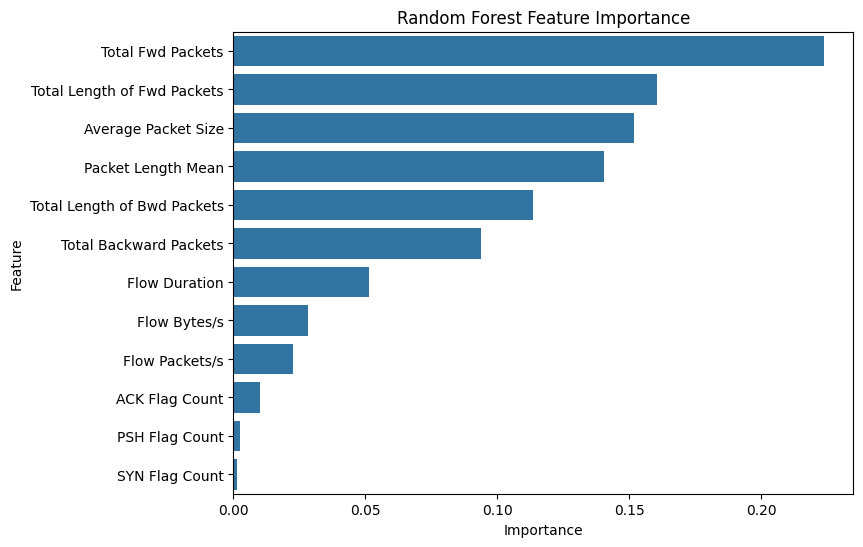

In [39]:
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# 14. Save Models and Preprocessing Objects

## 14.1 Save Both Models, Scaler, and Feature List

In [40]:
MODEL_DIR = os.path.join(DATA_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(logistic_model, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
joblib.dump(random_forest_model, os.path.join(MODEL_DIR, "random_forest.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(selected_features, os.path.join(MODEL_DIR, "selected_features.pkl"))

print("Saved files:")
print(os.listdir(MODEL_DIR))

Saved files:
['logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl', 'selected_features.pkl']


# 15. Test Saved Model on Sample Traffic

## 15.1 Load Saved Random Forest Model

In [41]:
loaded_rf = joblib.load(os.path.join(MODEL_DIR, "random_forest.pkl"))
loaded_scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
loaded_features = joblib.load(os.path.join(MODEL_DIR, "selected_features.pkl"))

print("Loaded model, scaler, and selected features successfully.")

Loaded model, scaler, and selected features successfully.


## 15.2 Predict Test

In [42]:
sample = model_df.drop("Label", axis=1).iloc[[0]]
sample_scaled = loaded_scaler.transform(sample[loaded_features])

prediction = loaded_rf.predict(sample_scaled)[0]

if prediction == 1:
    print("Prediction: DDoS Attack")
else:
    print("Prediction: BENIGN Traffic")

Prediction: BENIGN Traffic


In [44]:
# Select one real DDoS sample from the dataset
ddos_sample = model_df[model_df["Label"] == 1].drop("Label", axis=1).iloc[[0]]

# Scale the sample using the loaded scaler
ddos_sample_scaled = loaded_scaler.transform(ddos_sample[loaded_features])

# Predict using the loaded Random Forest model
prediction = loaded_rf.predict(ddos_sample_scaled)[0]

if prediction == 1:
    print("Prediction: DDoS Attack")
else:
    print("Prediction: BENIGN Traffic")

Prediction: DDoS Attack


# 16. Final Conclusion

The notebook performed an end-to-end workflow:

1. Loaded CIC-IDS 2017 BENIGN and DDoS traffic data.
2. Conducted exploratory data analysis.
3. Cleaned duplicates, missing values, and infinite values.
4. Removed potential leakage columns.
5. Selected meaningful traffic-based features.
6. Trained two required models:
   - Logistic Regression
   - Random Forest
7. Compared the models using Accuracy, Precision, Recall, F1 Score, ROC AUC, confusion matrices, and cross-validation.
8. Saved the trained models and preprocessing objects for future deployment.

Exploratory Data Analysis (EDA) waa marxalad muhiim ah oo lagu fahmo dataset-ka ka hor inta aan machine learning model la tababarin. Mashruucan, EDA waxaa loo isticmaalay in lagu baaro network traffic dataset-ka, lana fahmo kala duwanaanshaha u dhexeeya BENIGN traffic iyo DDoS attack.

Waxaa la hubiyay cabbirka dataset-ka, missing values, duplicate rows, data types, label distribution, feature distribution, outliers, iyo correlation-ka u dhexeeya features-ka. Natiijada EDA waxay naga caawisay in dataset-ka la nadiifiyo, features muhiim ah la doorto, kadibna loo diyaariyo training-ka labada models: Logistic Regression iyo Random Forest.